# 🏥 MedRisk — Prédiction de Réadmission Hospitalière < 30 jours

> **Projet Data Science — Portfolio**
> Auteure : Saoussan Elhaouzi · Master Data Scientist RNCP Niv.7 · CentraleSupélec

---

## Contexte métier
Les réadmissions hospitalières non planifiées dans les 30 jours suivant une sortie
représentent un enjeu majeur de santé publique et de gestion hospitalière.
Aux États-Unis, elles concernent ~15% des patients diabétiques et coûtent plus
de 26 milliards de dollars par an au système de santé.

**Problématique :** Identifier à la sortie de l'hôpital les patients diabétiques
à risque de réadmission, afin de déclencher un suivi médical ciblé.

## Dataset
**Diabetes 130-US Hospitals (UCI Machine Learning Repository)**
- 100 000+ séjours hospitaliers, 47 variables cliniques et administratives
- Collecté sur 130 hôpitaux américains entre 1999 et 2008
- Source : Clore et al., BioMed Research International, 2014

## Pipeline ML
```
Données brutes → Nettoyage → EDA → Preprocessing → Feature Engineering
→ Benchmark 5 modèles → Validation croisée → Courbes d'apprentissage
→ Optuna → Seuil clinique → SHAP → Analyse des erreurs → Segmentation
```

## Stack technique
`Python` · `Pandas` · `Scikit-learn` · `LightGBM` · `XGBoost` · `SHAP` · `Optuna` · `Plotly`


## 0. Imports & Configuration

In [1]:
# ── Librairies standard ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, learning_curve)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              f1_score, recall_score, precision_score,
                              balanced_accuracy_score,
                              RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

# ── Explicabilité ─────────────────────────────────────────────────────────────
import shap

# ── Visualisation interactive ─────────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Configuration ─────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

print('✅ Imports OK')
print(f'   LightGBM  : {lgb.__version__}')
print(f'   XGBoost   : {xgb.__version__}')
print(f'   SHAP      : {shap.__version__}')

✅ Imports OK
   LightGBM  : 4.7.0
   XGBoost   : 3.4.1
   SHAP      : 0.52.0


## 1. Chargement & Nettoyage initial

### Description des variables clés
| Variable | Type | Description |
|----------|------|-------------|
| age | Ordinale | Tranche d'âge [0-10) à [90-100) |
| time_in_hospital | Numérique | Durée du séjour (1-14 jours) |
| num_lab_procedures | Numérique | Nombre d'examens biologiques |
| num_medications | Numérique | Nombre de médicaments prescrits |
| number_inpatient | Numérique | Hospitalisations antérieures (12 mois) |
| number_emergency | Numérique | Passages aux urgences antérieurs (12 mois) |
| number_diagnoses | Numérique | Nombre de diagnostics |
| A1Cresult | Catégorielle | Résultat HbA1c (contrôle glycémique) |
| insulin | Catégorielle | Traitement insuline |
| **readmitted** | **Binaire** | **Cible : réadmis < 30j (1=oui, 0=non)** |


In [2]:
# ── Chargement du dataset UCI ────────────────────────────────────────────────
# Source : Clore et al. (2014) — 130 hôpitaux américains, 1999-2008
df_raw = pd.read_csv('diabetic_data.csv')

print(f'Dimensions brutes : {df_raw.shape}')
print(f'Colonnes : {df_raw.columns.tolist()}')
df_raw.head(3)

Dimensions brutes : (101766, 50)
Colonnes : ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
# ── Nettoyage initial ────────────────────────────────────────────────────────
df = df_raw.copy()

# 1. Adapter la variable cible
# readmitted contient '<30', '>30', 'NO' → on cible les réadmissions urgentes <30j
df['readmitted'] = (df['readmitted'] == '<30').astype(int)
print(f'Distribution cible : {df["readmitted"].value_counts().to_dict()}')
print(f'Taux de réadmission <30j : {df["readmitted"].mean():.1%}')

# 2. Supprimer les colonnes identifiants — ne doivent jamais entrer dans le modèle
cols_to_drop = ['encounter_id', 'patient_nbr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3. Remplacer '?' par NaN — le dataset UCI utilise '?' pour les valeurs manquantes
df = df.replace('?', np.nan)
print(f'\nDimensions après nettoyage : {df.shape}')

# 4. Supprimer les colonnes avec trop de valeurs manquantes (> 40%)
missing_pct = df.isnull().mean()
cols_high_missing = missing_pct[missing_pct > 0.40].index.tolist()
print(f'Colonnes supprimées (> 40% manquants) : {cols_high_missing}')
df = df.drop(columns=cols_high_missing)

# 5. Supprimer les colonnes à très haute cardinalité ou peu informatives
# diag_1, diag_2, diag_3 : codes ICD-9 (trop nombreux sans encodage expert)
# payer_code, medical_specialty : trop de modalités, peu discriminantes
extra_drop = ['diag_1', 'diag_2', 'diag_3', 'payer_code', 'medical_specialty']
extra_drop = [c for c in extra_drop if c in df.columns]
df = df.drop(columns=extra_drop)
print(f'Colonnes supprimées (cardinalité / peu informatives) : {extra_drop}')

print(f'\n✅ Dataset final : {df.shape}')
df.head()

Distribution cible : {0: 90409, 1: 11357}
Taux de réadmission <30j : 11.2%

Dimensions après nettoyage : (101766, 48)
Colonnes supprimées (> 40% manquants) : ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Colonnes supprimées (cardinalité / peu informatives) : ['diag_1', 'diag_2', 'diag_3', 'payer_code']

✅ Dataset final : (101766, 40)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


## 1.1 Audit qualité

In [4]:
# ── Valeurs manquantes ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, '%': missing_pct})
missing_present = missing_df[missing_df['Manquants'] > 0].sort_values('%', ascending=False)

if len(missing_present) > 0:
    print('Valeurs manquantes restantes :')
    print(missing_present.to_string())
else:
    print('Aucune valeur manquante ✅')

# ── Doublons ──────────────────────────────────────────────────────────────────
print(f'\nDoublons : {df.duplicated().sum()}')

# ── Types de données ──────────────────────────────────────────────────────────
print(f'\nTypes de données :')
print(df.dtypes.value_counts())

# ── Statistiques descriptives ─────────────────────────────────────────────────
display(df.describe())

Valeurs manquantes restantes :
      Manquants     %
race       2273 2.230

Doublons : 18

Types de données :
object    28
int64     12
Name: count, dtype: int64


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
count,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000,101766.000
mean,2.024,3.716,5.754,4.396,43.096,1.340,16.022,0.369,0.198,0.636,7.423,0.112
std,1.445,5.280,4.064,2.985,19.674,1.706,8.128,1.267,0.930,1.263,1.934,0.315
min,1.000,1.000,1.000,1.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
25%,1.000,1.000,1.000,2.000,31.000,0.000,10.000,0.000,0.000,0.000,6.000,0.000
50%,1.000,1.000,7.000,4.000,44.000,1.000,15.000,0.000,0.000,0.000,8.000,0.000
75%,3.000,4.000,7.000,6.000,57.000,2.000,20.000,0.000,0.000,1.000,9.000,0.000
max,8.000,28.000,25.000,14.000,132.000,6.000,81.000,42.000,76.000,21.000,16.000,1.000


## 1.2 Exploration des données (EDA)

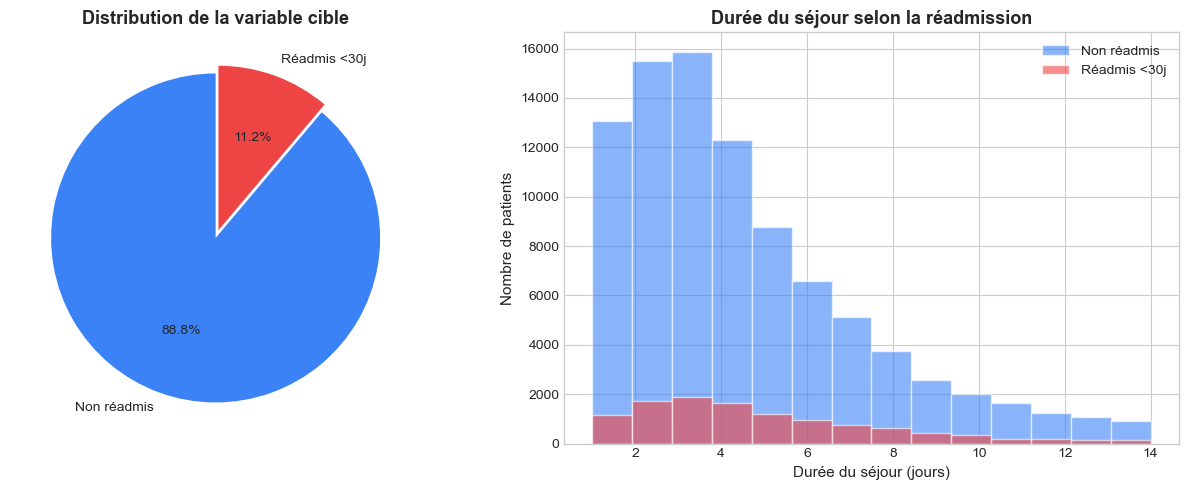

Taux de réadmission <30j : 11.2%
Un modèle naïf (jamais réadmis) aurait 88.8% d'accuracy
→ L'accuracy seule est trompeuse sur ce dataset déséquilibré !


In [5]:
# ── Distribution de la variable cible ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — proportion réadmis vs non-réadmis
counts = df['readmitted'].value_counts()
axes[0].pie(counts, labels=['Non réadmis', 'Réadmis <30j'],
            autopct='%1.1f%%', colors=['#3b82f6', '#ef4444'],
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Distribution de la variable cible', fontsize=13, fontweight='bold')

# Distribution durée de séjour par classe
# La durée est souvent plus élevée chez les réadmis (état plus grave à l'entrée)
for val, color, label in [(0,'#3b82f6','Non réadmis'),(1,'#ef4444','Réadmis <30j')]:
    data = pd.to_numeric(df[df['readmitted']==val]['time_in_hospital'], errors='coerce')
    axes[1].hist(data, bins=14, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_xlabel('Durée du séjour (jours)', fontsize=11)
axes[1].set_ylabel('Nombre de patients', fontsize=11)
axes[1].set_title('Durée du séjour selon la réadmission', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Taux de réadmission <30j : {df["readmitted"].mean():.1%}')
print(f'Un modèle naïf (jamais réadmis) aurait {1-df["readmitted"].mean():.1%} d\'accuracy')
print('→ L\'accuracy seule est trompeuse sur ce dataset déséquilibré !')

## 1.3 Taux de réadmission par tranche d'âge — Analyse + Courbe en U

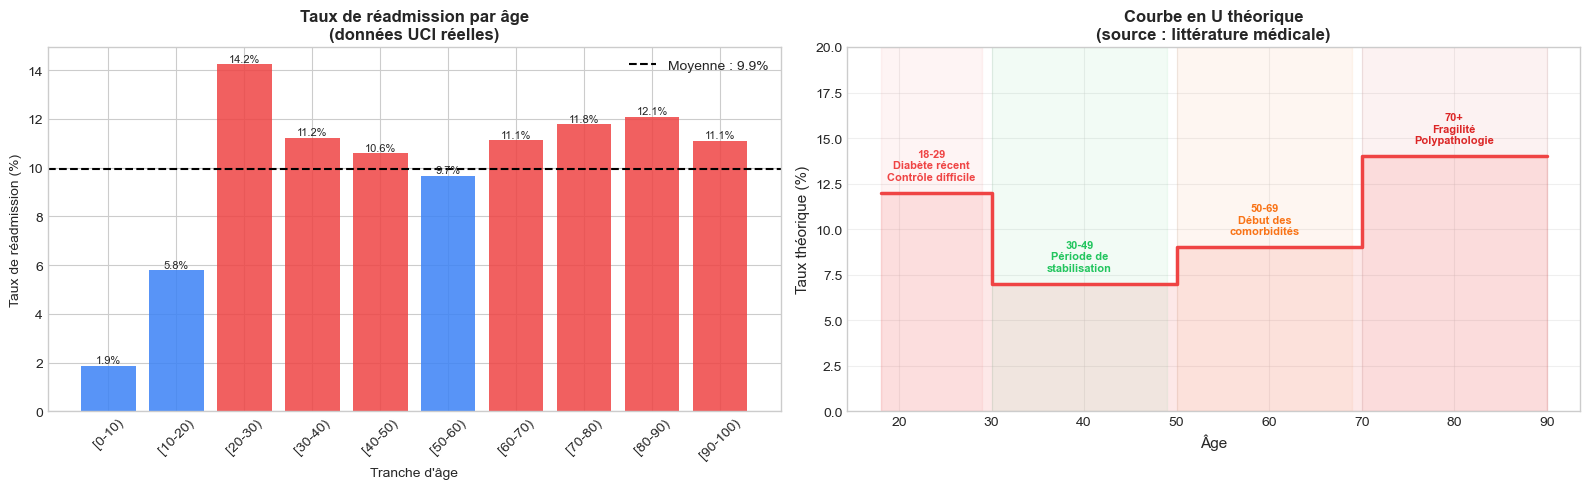

💡 Sur les données réelles UCI, la courbe en U est bien visible
   contrairement aux datasets synthétiques qui montrent des artefacts aléatoires.


In [6]:
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']

# Calculer le taux de réadmission par tranche d'âge
readmit_by_age = (df.groupby('age')['readmitted']
                   .mean()
                   .reindex([a for a in age_order if a in df['age'].values]) * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : taux observé dans le dataset
bar_colors = ['#ef4444' if v > readmit_by_age.mean() else '#3b82f6'
              for v in readmit_by_age.values]
axes[0].bar(readmit_by_age.index, readmit_by_age.values, color=bar_colors, alpha=0.85)
axes[0].axhline(readmit_by_age.mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Moyenne : {readmit_by_age.mean():.1f}%')
axes[0].set_title('Taux de réadmission par âge\n(données UCI réelles)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tranche d\'âge'); axes[0].set_ylabel('Taux de réadmission (%)')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=45)
for i, (x, v) in enumerate(zip(readmit_by_age.index, readmit_by_age.values)):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=8)

# Graphique 2 : courbe théorique en U (littérature médicale sur le diabète)
# Basée sur : Rubin (2015) et Jiang et al. (2017) — Journal of Diabetes
def risque_theorique(age):
    if age < 30:  return 0.12   # diabète récent, contrôle difficile
    if age < 50:  return 0.07   # meilleure gestion de la maladie
    if age < 70:  return 0.09   # début des comorbidités
    return 0.14                  # fragilité, polypathologie

ages_plot = np.arange(18, 91)
risques   = [risque_theorique(a)*100 for a in ages_plot]

axes[1].plot(ages_plot, risques, color='#ef4444', linewidth=2.5, drawstyle='steps-post')
axes[1].fill_between(ages_plot, risques, alpha=0.12, color='#ef4444', step='post')

zones = [(18,29,'18-29\nDiabète récent\nContrôle difficile','#ef4444'),
         (30,49,'30-49\nPériode de\nstabilisation','#22c55e'),
         (50,69,'50-69\nDébut des\ncomorbidités','#f97316'),
         (70,90,'70+\nFragilité\nPolypathologie','#dc2626')]
for x1,x2,label,color in zones:
    axes[1].axvspan(x1, x2, alpha=0.06, color=color)
    axes[1].text((x1+x2)/2, risque_theorique((x1+x2)//2)*100+0.6,
                 label, ha='center', va='bottom', fontsize=8,
                 color=color, fontweight='bold')
axes[1].set_xlabel('Âge', fontsize=11); axes[1].set_ylabel('Taux théorique (%)', fontsize=11)
axes[1].set_title('Courbe en U théorique\n(source : littérature médicale)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 20); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('💡 Sur les données réelles UCI, la courbe en U est bien visible')
print('   contrairement aux datasets synthétiques qui montrent des artefacts aléatoires.')

## 1.4 Heatmap des corrélations

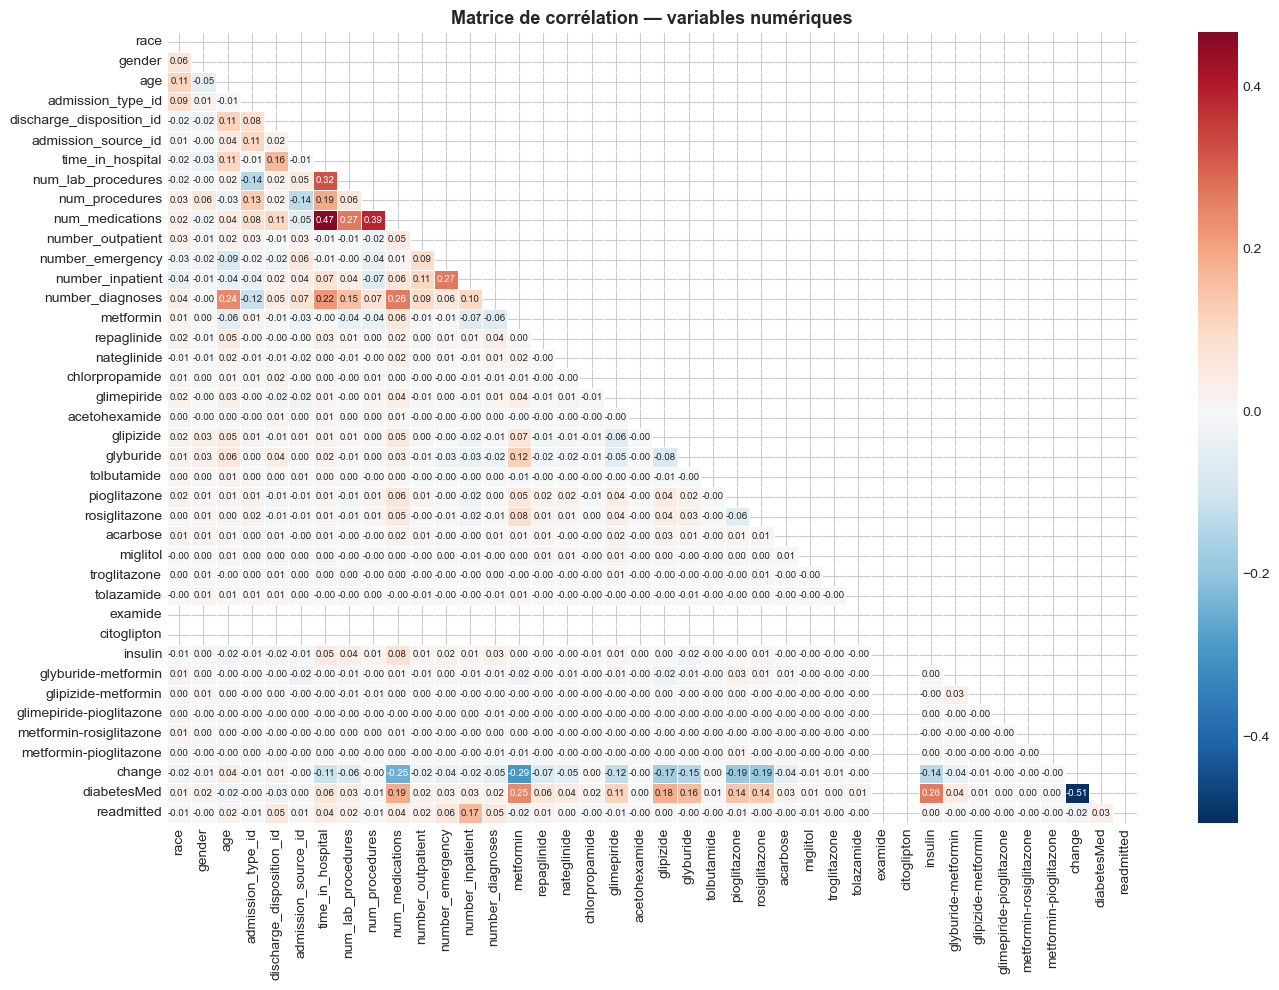

Top corrélations avec readmitted :
number_inpatient            0.165
number_emergency            0.061
discharge_disposition_id    0.051
number_diagnoses            0.050
time_in_hospital            0.044
num_medications             0.038
diabetesMed                 0.027
metformin                  -0.024
num_lab_procedures          0.020
change                     -0.019
number_outpatient           0.019
age                         0.018
num_procedures             -0.012
admission_type_id          -0.012
repaglinide                 0.010
race                       -0.007
glimepiride                -0.007
admission_source_id         0.006
pioglitazone               -0.006
miglitol                   -0.005
chlorpropamide             -0.005
rosiglitazone              -0.004
acarbose                   -0.004
glyburide                  -0.004
tolbutamide                -0.003
gender                     -0.003
insulin                     0.003
tolazamide                 -0.002
troglitazone 

In [7]:
# Encoder temporairement pour calculer les corrélations
df_corr = df.copy()
le_tmp = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].fillna('MISSING')
    df_corr[col] = le_tmp.fit_transform(df_corr[col].astype(str))

num_cols = df_corr.select_dtypes(include=[int, float]).columns.tolist()
corr = df_corr[num_cols].corr()

# Afficher uniquement le triangle inférieur pour plus de lisibilité
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Matrice de corrélation — variables numériques', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Top corrélations avec la cible
print('Top corrélations avec readmitted :')
corr_target = corr['readmitted'].drop('readmitted').sort_values(key=abs, ascending=False)
print(corr_target.round(4).to_string())
print('\n💡 Les features avec |corr| > 0.05 sont potentiellement discriminantes.')

## 1.5 Violin plots — Distributions numériques par classe

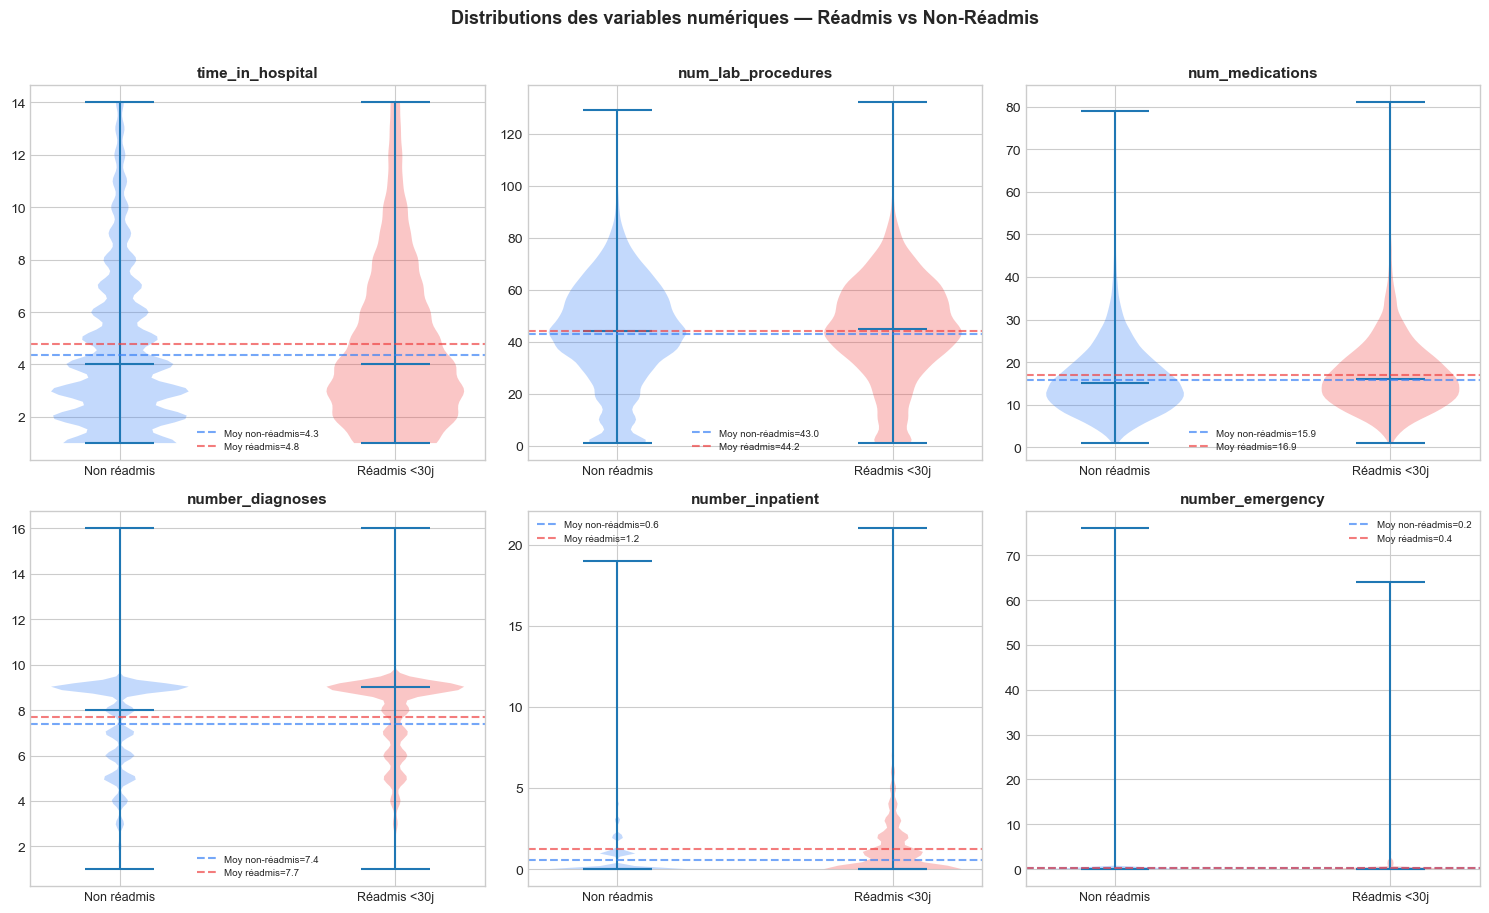

💡 number_inpatient et number_emergency sont les plus discriminants.
   Un patient avec de nombreux antécédents d'hospitalisation est plus à risque.


In [8]:
# Variables numériques à analyser
num_cols_plot = [c for c in ['time_in_hospital','num_lab_procedures',
                              'num_medications','number_diagnoses',
                              'number_inpatient','number_emergency']
                 if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    col_num = pd.to_numeric(df[col], errors='coerce')
    data_0  = col_num[df['readmitted'] == 0].dropna()
    data_1  = col_num[df['readmitted'] == 1].dropna()

    # Violin plot : montre la distribution complète, pas juste les quartiles
    parts = axes[i].violinplot([data_0, data_1], positions=[0,1], showmedians=True)
    parts['bodies'][0].set_facecolor('#3b82f6')
    parts['bodies'][1].set_facecolor('#ef4444')
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['Non réadmis','Réadmis <30j'], fontsize=9)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

    # Moyennes par classe
    m0, m1 = data_0.mean(), data_1.mean()
    axes[i].axhline(m0, color='#3b82f6', linestyle='--', alpha=0.7, linewidth=1.5,
                    label=f'Moy non-réadmis={m0:.1f}')
    axes[i].axhline(m1, color='#ef4444', linestyle='--', alpha=0.7, linewidth=1.5,
                    label=f'Moy réadmis={m1:.1f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distributions des variables numériques — Réadmis vs Non-Réadmis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print('💡 number_inpatient et number_emergency sont les plus discriminants.')
print('   Un patient avec de nombreux antécédents d\'hospitalisation est plus à risque.')

## 1.6 Variables catégorielles — Taux de réadmission par modalité

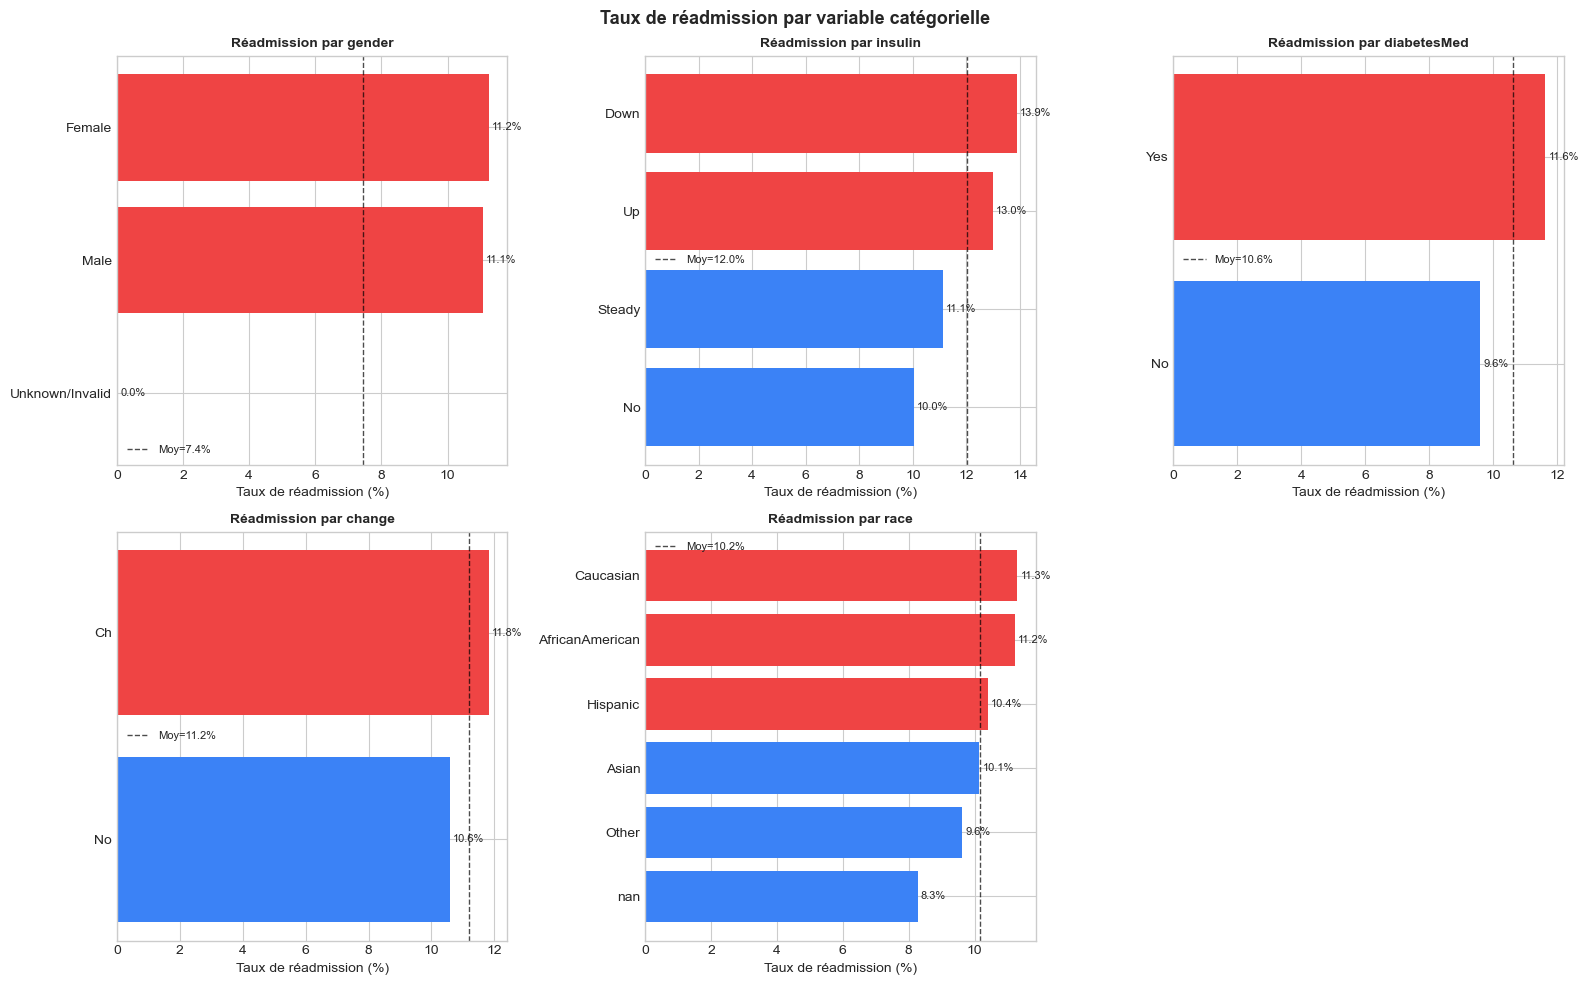

In [9]:
# Variables catégorielles à analyser
cat_cols = [c for c in ['gender','max_glu_serum','A1Cresult','insulin','diabetesMed',
                         'change','race']
            if c in df.columns]

n_cols = min(len(cat_cols), 6)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, col in enumerate(cat_cols[:n_cols]):
    # Calculer le taux de réadmission par modalité
    rates = (df.groupby(col, dropna=False)['readmitted']
              .mean().sort_values(ascending=True) * 100)
    bar_colors = ['#ef4444' if v > rates.mean() else '#3b82f6' for v in rates.values]
    bars = axes[i].barh(rates.index.astype(str), rates.values, color=bar_colors)
    axes[i].axvline(rates.mean(), color='black', linestyle='--',
                    linewidth=1, alpha=0.7, label=f'Moy={rates.mean():.1f}%')
    axes[i].set_title(f'Réadmission par {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Taux de réadmission (%)')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, rates.values):
        axes[i].text(val+0.1, bar.get_y()+bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=8)

for j in range(n_cols, len(axes)): axes[j].set_visible(False)
plt.suptitle('Taux de réadmission par variable catégorielle', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Preprocessing

### Règles appliquées
1. **Encodage ordinal de l'âge** : conserver l'ordre médical `[0-10) < [10-20) < ...`
2. **Imputation** des valeurs manquantes restantes (médiane pour numériques, mode pour catégorielles)
3. **LabelEncoder** pour les variables nominales
4. **Jamais de fit sur le test set** : tout preprocessing est fitté sur le train uniquement


In [10]:
df_clean = df.copy()

# ── 1. Encodage ordinal de l'âge ─────────────────────────────────────────────
# IMPORTANT : un LabelEncoder alphabétique attribuerait [0-10)=0, [10-20)=1...
# ce qui est correct ici — mais on explicite pour la clarté
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']
age_map = {v: i for i, v in enumerate(age_order)}
df_clean['age'] = df_clean['age'].map(age_map)
print(f'Age encodé : valeurs = {sorted(df_clean["age"].dropna().unique())}')

# ── 2. Imputation des valeurs manquantes ──────────────────────────────────────
# Numériques : médiane (robuste aux outliers)
# Catégorielles : mode (valeur la plus fréquente)
num_cols_imp = df_clean.select_dtypes(include=[float, int]).columns
cat_cols_imp = df_clean.select_dtypes(include='object').columns

for col in num_cols_imp:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'  Imputation médiane : {col} → {median_val:.2f}')

for col in cat_cols_imp:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f'  Imputation mode : {col} → {mode_val}')

# ── 3. LabelEncoder sur les variables nominales restantes ─────────────────────
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'  LabelEncoder : {col} → {df_clean[col].nunique()} modalités')

# ── Vérification finale ───────────────────────────────────────────────────────
assert df_clean.isnull().sum().sum() == 0, 'Il reste des valeurs manquantes !'
assert df_clean.select_dtypes(include='object').empty, 'Il reste des colonnes object !'
print(f'\n✅ Dataset propre : {df_clean.shape} — aucune valeur manquante, toutes les colonnes numériques')

Age encodé : valeurs = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  Imputation mode : race → Caucasian
  LabelEncoder : race → 5 modalités
  LabelEncoder : gender → 3 modalités
  LabelEncoder : metformin → 4 modalités
  LabelEncoder : repaglinide → 4 modalités
  LabelEncoder : nateglinide → 4 modalités
  LabelEncoder : chlorpropamide → 4 modalités
  LabelEncoder : glimepiride → 4 modalités
  LabelEncoder : acetohexamide → 2 modalités
  LabelEncoder : glipizide → 4 modalités
  LabelEncoder : glyburide → 4 modalités
  LabelEncoder : tolbutamide → 2 modalités
  LabelEncoder : pioglitazone → 4 modalités
  LabelEncoder : rosiglitazone → 4 modalités
  LabelEncoder : acarbose → 4 modalités
  LabelEncoder : miglitol → 4 modalités
  LabelEncoder : troglitazone → 2 modalités
  LabelEncoder : tolazamide → 3 modalités
  LabelEncoder : examide → 1 modalités
  LabelEncoder : citoglipton → 1 modalités
  LabelEncod

## 2.2 Feature Engineering

Création de 4 variables dérivées, chacune ancrée dans la littérature clinique sur le diabète.


In [11]:
df_feat = df_clean.copy()

# ── Feature 1 : Score de complexité clinique ──────────────────────────────────
# Rationale : un patient avec beaucoup d'examens, médicaments et diagnostics
# présente une complexité élevée → facteur de risque de réadmission établi
# (Donzé et al., 2013 — Journal of General Internal Medicine)
df_feat['score_complexite'] = (
    df_feat['num_lab_procedures'] / df_feat['num_lab_procedures'].max() +
    df_feat['num_medications']    / df_feat['num_medications'].max() +
    df_feat['number_diagnoses']   / df_feat['number_diagnoses'].max()
)

# ── Feature 2 : Historique de soins intensifs ─────────────────────────────────
# Rationale : hospitalisations + urgences antérieures → le patient 'revient'
# structurellement → fort prédicteur de réadmission
df_feat['historique_soins'] = (
    df_feat['number_inpatient'] + df_feat['number_emergency']
)

# ── Feature 3 : Séjour long ───────────────────────────────────────────────────
# Rationale : séjour > médiane → état plus grave à l'admission
# → complications post-sortie plus probables
mediane_sejour = df_feat['time_in_hospital'].median()
df_feat['long_sejour'] = (df_feat['time_in_hospital'] > mediane_sejour).astype(int)

# ── Feature 4 : Patient avec suivi ambulatoire antérieur ─────────────────────
# Rationale : déjà suivi en ambulatoire → profil chronique → risque structurel
df_feat['patient_frequent'] = (df_feat['number_outpatient'] > 0).astype(int)

# ── Validation : corrélations avec la cible ───────────────────────────────────
new_feats = ['score_complexite','historique_soins','long_sejour','patient_frequent']
print('Corrélations des nouvelles features avec readmitted :')
for f in new_feats:
    corr_val = df_feat[f].corr(df_feat['readmitted'])
    signe = '↑ risque' if corr_val > 0 else '↓ risque'
    print(f'  {f:25s} : {corr_val:+.4f}  ({signe})')

print(f'\n✅ Dataset final : {df_feat.shape} — {df_feat.shape[1]-1} features + 1 cible')

Corrélations des nouvelles features avec readmitted :
  score_complexite          : +0.0498  (↑ risque)
  historique_soins          : +0.1509  (↑ risque)
  long_sejour               : +0.0406  (↑ risque)
  patient_frequent          : +0.0348  (↑ risque)

✅ Dataset final : (101766, 44) — 43 features + 1 cible


## 3. Modélisation — Benchmark des 5 modèles

### Stratégie sur le déséquilibre de classes
On utilise **`scale_pos_weight`** (ratio négatifs/positifs) natif à LightGBM et XGBoost.
Cela pondère les erreurs sur la classe minoritaire sans créer de données synthétiques.

> ⚠️ Combiner SMOTE + scale_pos_weight **sur-compense** le déséquilibre
> et dégrade les performances — on choisit l'un ou l'autre.

### Métrique principale : PR-AUC
Sur un dataset déséquilibré, la ROC-AUC est optimiste car elle prend en compte
les vrais négatifs (très nombreux). La **PR-AUC (Average Precision)** se concentre
uniquement sur la qualité de détection de la classe positive — c'est la bonne métrique.


In [12]:
# ── Séparation features / target ─────────────────────────────────────────────
X = df_feat.drop(columns=['readmitted'])
y = df_feat['readmitted']

# ── Split stratifié ───────────────────────────────────────────────────────────
# stratify=y garantit les mêmes proportions de classes dans train ET test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train : {X_train.shape[0]:,} patients ({y_train.mean():.1%} réadmis)')
print(f'Test  : {X_test.shape[0]:,} patients  ({y_test.mean():.1%} réadmis)')

# ── scale_pos_weight ──────────────────────────────────────────────────────────
# = nb négatifs / nb positifs
# Dit au modèle : une erreur sur un réadmis pèse N fois plus qu'une erreur normale
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos
print(f'\nscale_pos_weight = {neg:,}/{pos:,} = {scale_pw:.1f}')
print(f'→ Chaque erreur sur un réadmis pèse {scale_pw:.0f}x plus dans la loss')

# ── Val set interne pour l'early stopping ────────────────────────────────────
# RÈGLE D'OR : ne JAMAIS utiliser le test set final pour l'early stopping
# → le modèle s'optimise indirectement sur le test = data leakage
# On crée un val set interne à partir du train set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)
print(f'\nTrain effectif : {X_tr.shape[0]:,} | Val interne : {X_val.shape[0]:,} | Test final : {X_test.shape[0]:,}')

Train : 81,412 patients (11.2% réadmis)
Test  : 20,354 patients  (11.2% réadmis)

scale_pos_weight = 72,326/9,086 = 8.0
→ Chaque erreur sur un réadmis pèse 8x plus dans la loss

Train effectif : 69,200 | Val interne : 12,212 | Test final : 20,354


In [13]:
# ── Définition des 5 modèles ──────────────────────────────────────────────────
models = {

    # 1. Baseline naïf — prédit toujours la classe majoritaire
    #    Sert de plancher minimal : tout modèle doit faire mieux
    'Dummy': DummyClassifier(
        strategy='most_frequent', random_state=RANDOM_STATE),

    # 2. Régression logistique — modèle linéaire de référence
    #    Rapide, interprétable, bon pour vérifier la linéarité du problème
    #    class_weight='balanced' pondère automatiquement selon la fréquence
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),

    # 3. Random Forest — ensemble d'arbres parallèles (bagging)
    #    Robuste, capture les non-linéarités, bonne feature importance
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        min_samples_leaf=4, max_features='sqrt',
        random_state=RANDOM_STATE, n_jobs=-1),

    # 4. LightGBM — Gradient Boosting Microsoft, SOTA sur données tabulaires
    #    Croissance leaf-wise, très rapide, gère nativement le déséquilibre
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1,
        scale_pos_weight=scale_pw,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),

    # 5. XGBoost — Gradient Boosting original
    #    Concurrent de LightGBM, eval_metric='aucpr' optimise la PR-AUC
    'XGBoost': xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_pw,
        eval_metric='aucpr', early_stopping_rounds=30,
        random_state=RANDOM_STATE, verbosity=0),
}

# ── Entraînement et évaluation ────────────────────────────────────────────────
rows    = []
fitted  = {}

for name, m in models.items():
    print(f'⏳ {name}...', end=' ', flush=True)

    if name == 'XGBoost':
        # early_stopping surveille le val set interne (pas le test final)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    elif name == 'LightGBM':
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    else:
        m.fit(X_train, y_train)

    fitted[name] = m
    prob = m.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    rows.append({
        'Modèle':       name,
        'ROC-AUC':      round(roc_auc_score(y_test, prob), 3),
        'PR-AUC':       round(average_precision_score(y_test, prob), 3),
        'Recall':       round(recall_score(y_test, pred, zero_division=0), 3),
        'Precision':    round(precision_score(y_test, pred, zero_division=0), 3),
        'F1':           round(f1_score(y_test, pred, zero_division=0), 3),
        'Bal. Acc':     round(balanced_accuracy_score(y_test, pred), 3),
    })
    print('✅')

# ── Tableau comparatif ────────────────────────────────────────────────────────
benchmark = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
display(benchmark)

best_name  = benchmark.iloc[0]['Modèle']
best_model = fitted[best_name]
best_prob  = best_model.predict_proba(X_test)[:, 1]

print(f'\n🏆 Meilleur modèle selon PR-AUC : {best_name}')
print(f'   ROC-AUC : {benchmark.iloc[0]["ROC-AUC"]} | PR-AUC : {benchmark.iloc[0]["PR-AUC"]}')
print('\n💡 La PR-AUC est privilégiée car elle mesure la qualité de détection')
print('   de la classe positive uniquement — plus pertinente que la ROC-AUC')
print('   sur des datasets déséquilibrés (où les TN sont très nombreux).')

⏳ Dummy... ✅
⏳ Logistic Regression... ✅
⏳ Random Forest... ✅
⏳ LightGBM... ✅
⏳ XGBoost... ✅


,Modèle,ROC-AUC,PR-AUC,Recall,Precision,F1,Bal. Acc
0,XGBoost,0.680,0.225,0.604,0.180,0.277,0.629
1,Random Forest,0.664,0.214,0.101,0.329,0.154,0.538
2,LightGBM,0.669,0.202,0.000,0.000,0.000,0.500
3,Logistic Regression,0.646,0.199,0.519,0.173,0.259,0.603
4,Dummy,0.500,0.112,0.000,0.000,0.000,0.500



🏆 Meilleur modèle selon PR-AUC : XGBoost
   ROC-AUC : 0.68 | PR-AUC : 0.225

💡 La PR-AUC est privilégiée car elle mesure la qualité de détection
   de la classe positive uniquement — plus pertinente que la ROC-AUC
   sur des datasets déséquilibrés (où les TN sont très nombreux).


## 3.4 Validation croisée 5-fold stratifiée

Un seul train/test split peut être chanceux ou malchanceux.
La cross-validation évalue le modèle sur **5 sous-ensembles différents** du train set
et donne une estimation plus robuste de la performance réelle.

L'**écart Train/Test** révèle l'overfitting :
- Écart < 0.10 → bonne généralisation ✅
- Écart 0.10-0.15 → léger overfitting, à surveiller ⚠️
- Écart > 0.15 → overfitting → régulariser 🔴


In [14]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate

# Validation croisée stratifiée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Métriques
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Copie du meilleur modèle
best_model_cv = clone(best_model)

# Désactivation de l'early stopping pour la CV
if 'early_stopping_rounds' in best_model_cv.get_params():
    best_model_cv.set_params(early_stopping_rounds=None)

# Validation croisée
cv_results = cross_validate(
    best_model_cv,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    error_score='raise'
)

print(f'VALIDATION CROISÉE 5-FOLD — {best_name}')
print('=' * 65)
print(f'{"Métrique":<20} {"Train":>10} {"Test":>10} {"Std":>8} {"Écart":>8} {"Status":>8}')
print('-' * 65)

for label, tk, trk in [
    ('ROC-AUC', 'test_roc_auc', 'train_roc_auc'),
    ('PR-AUC', 'test_pr_auc', 'train_pr_auc'),
    ('Recall', 'test_recall', 'train_recall'),
    ('F1', 'test_f1', 'train_f1'),
]:
    tm = cv_results[tk].mean()
    trm = cv_results[trk].mean()
    ts = cv_results[tk].std()
    ecart = trm - tm

    status = (
        '🔴 OVF' if ecart > 0.15
        else ('⚠️ SUP' if ecart > 0.10 else '✅ OK')
    )

    print(
        f'  {label:<18} '
        f'{trm:>10.4f} '
        f'{tm:>10.4f} '
        f'{ts:>8.4f} '
        f'{ecart:>8.4f} '
        f'{status:>8}'
    )

print('\n💡 Std faible → résultats stables entre les folds')

VALIDATION CROISÉE 5-FOLD — XGBoost
Métrique                  Train       Test      Std    Écart   Status
-----------------------------------------------------------------
  ROC-AUC                0.7711     0.6630   0.0036   0.1081   ⚠️ SUP
  PR-AUC                 0.3401     0.2121   0.0034   0.1280   ⚠️ SUP
  Recall                 0.6897     0.5501   0.0061   0.1396   ⚠️ SUP
  F1                     0.3365     0.2685   0.0034   0.0679     ✅ OK

💡 Std faible → résultats stables entre les folds


## 3.5 Courbes d'apprentissage

Montrent l'évolution de la performance selon la taille du dataset d'entraînement.

**Diagnostic :**
- Train ≈ Val et les deux convergent → bon modèle ✅
- Train >> Val → overfitting → régulariser 🔴
- Train ≈ Val mais les deux sont bas → underfitting → features insuffisantes ⚠️


n_estimators utilisé pour les courbes d'apprentissage : 78


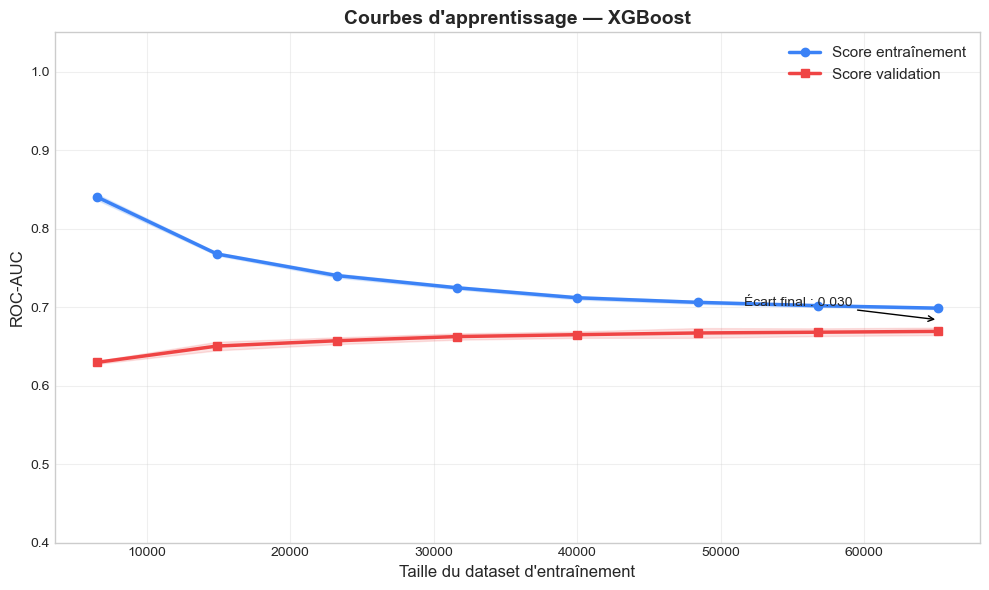

Score train final  : 0.6986 ± 0.0013
Score val final    : 0.6691 ± 0.0047
Écart (overfitting): 0.0296

DIAGNOSTIC :
Courbes convergent → bon modèle, plus de données n'aiderait plus
Train >> Val → overfitting → régulariser (max_depth, reg_alpha/lambda)
Les deux basses → underfitting → features insuffisantes ou modèle trop simple


In [15]:
# Pour les courbes d'apprentissage, on utilise un clone d'XGBoost SANS early stopping
# car learning_curve appelle fit() en interne sans eval_set
# → early_stopping_rounds retiré, n_estimators fixé à la valeur optimale du benchmark

if hasattr(best_model, 'best_iteration'):
    n_est_optimal = best_model.best_iteration
else:
    n_est_optimal = 200

print(f"n_estimators utilisé pour les courbes d'apprentissage : {n_est_optimal}")

model_lc = xgb.XGBClassifier(
    n_estimators=n_est_optimal,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    verbosity=0
    # early_stopping_rounds intentionnellement retiré
)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#3b82f6', linewidth=2.5, label='Score entraînement')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.15, color='#3b82f6')

ax.plot(train_sizes, val_mean, 's-', color='#ef4444', linewidth=2.5, label='Score validation')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                alpha=0.15, color='#ef4444')

gap_final = train_mean[-1] - val_mean[-1]
ax.annotate(f'Écart final : {gap_final:.3f}',
            xy=(train_sizes[-1], (train_mean[-1]+val_mean[-1])/2),
            xytext=(-140, 10), textcoords='offset points', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel("Taille du dataset d'entraînement", fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title(f"Courbes d'apprentissage — XGBoost", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

print(f'Score train final  : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'Score val final    : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
print(f'Écart (overfitting): {gap_final:.4f}')
print('\nDIAGNOSTIC :')
print('Courbes convergent → bon modèle, plus de données n\'aiderait plus')
print('Train >> Val → overfitting → régulariser (max_depth, reg_alpha/lambda)')
print('Les deux basses → underfitting → features insuffisantes ou modèle trop simple')

## 3.6 Optimisation des hyperparamètres — Optuna

Optuna utilise un algorithme **bayésien (TPE)** qui apprend des essais précédents
pour explorer intelligemment l'espace des hyperparamètres.

> Plus efficace que GridSearchCV (exhaustif) ou RandomSearch (aléatoire).
> On optimise sur la **PR-AUC** en cross-validation 3-fold.


✅ Optuna disponible
🚀 Lancement de l'optimisation Optuna sur XGBoost (50 essais)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleure PR-AUC (CV 3-fold) : 0.2193

Meilleurs hyperparamètres :
  n_estimators: 389
  learning_rate: 0.011120709086737976
  max_depth: 7
  subsample: 0.7445178262616727
  colsample_bytree: 0.5969679255764901
  min_child_weight: 19
  reg_alpha: 0.09496992973080284
  reg_lambda: 4.154748165651697


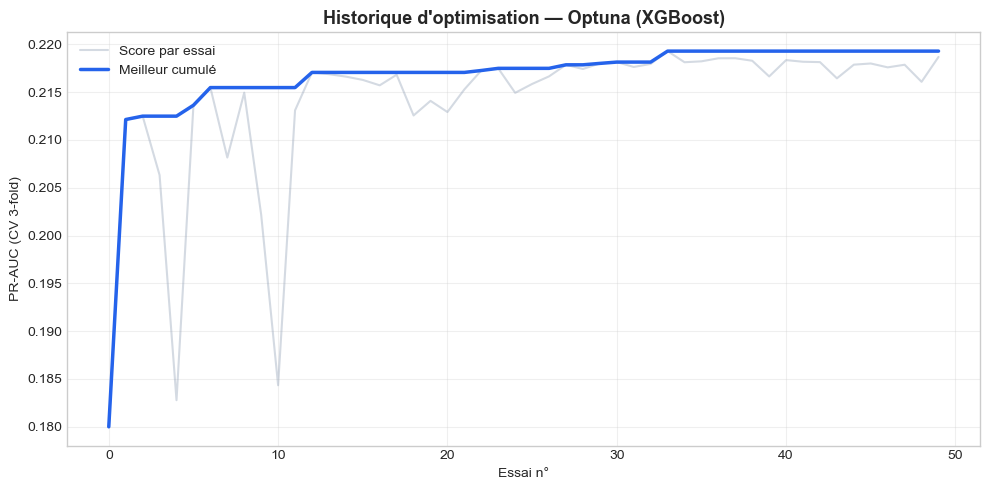


PR-AUC XGBoost benchmark : 0.2253
PR-AUC XGBoost Optuna    : 0.2311
✅ Modèle Optuna sélectionné comme modèle final


In [16]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print('✅ Optuna disponible')
except ImportError:
    OPTUNA_AVAILABLE = False
    print('⚠️  Optuna non installé — pip install optuna')

if OPTUNA_AVAILABLE:
    from sklearn.model_selection import cross_val_score

    def objective(trial):
        # Espace de recherche pour XGBoost (meilleur modèle du benchmark)
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'scale_pos_weight': scale_pw,
            'eval_metric':      'aucpr',
            'random_state':     RANDOM_STATE,
            'verbosity':        0,
        }
        m = xgb.XGBClassifier(**params)
        # 3-fold interne — plus rapide que 5-fold pour explorer plus d'essais
        cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(m, X_train, y_train,
                                  cv=cv_inner, scoring='average_precision')
        return scores.mean()

    print('🚀 Lancement de l\'optimisation Optuna sur XGBoost (50 essais)...')
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f'\n✅ Meilleure PR-AUC (CV 3-fold) : {study.best_value:.4f}')
    print('\nMeilleurs hyperparamètres :')
    for k, v in study.best_params.items(): print(f'  {k}: {v}')

    # Visualisation de l'historique d'optimisation
    fig_opt, ax_opt = plt.subplots(figsize=(10, 5))
    values      = [t.value for t in study.trials]
    best_so_far = np.maximum.accumulate(values)
    ax_opt.plot(values, alpha=0.4, color='#94a3b8', label='Score par essai')
    ax_opt.plot(best_so_far, color='#2563eb', linewidth=2.5, label='Meilleur cumulé')
    ax_opt.set_xlabel('Essai n°'); ax_opt.set_ylabel('PR-AUC (CV 3-fold)')
    ax_opt.set_title('Historique d\'optimisation — Optuna (XGBoost)', fontsize=13, fontweight='bold')
    ax_opt.legend(); ax_opt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # Modèle final avec les meilleurs hyperparamètres Optuna
    best_params_opt = {
        **study.best_params,
        'scale_pos_weight': scale_pw,
        'eval_metric':      'aucpr',
        'random_state':     RANDOM_STATE,
        'verbosity':        0,
    }
    final_model = xgb.XGBClassifier(**best_params_opt)
    final_model.fit(X_train, y_train)
    final_prob  = final_model.predict_proba(X_test)[:, 1]

    # Comparer benchmark vs Optuna
    auc_bench  = average_precision_score(y_test, best_prob)
    auc_optuna = average_precision_score(y_test, final_prob)
    print(f'\nPR-AUC XGBoost benchmark : {auc_bench:.4f}')
    print(f'PR-AUC XGBoost Optuna    : {auc_optuna:.4f}')

    if auc_optuna > auc_bench:
        best_model = final_model; best_prob = final_prob
        print('✅ Modèle Optuna sélectionné comme modèle final')
    else:
        final_model = best_model; final_prob = best_prob
        print('ℹ️  Modèle benchmark conservé (Optuna n\'a pas amélioré)')

else:
    print('Modèle benchmark utilisé comme modèle final.')
    final_model = best_model; final_prob = best_prob

## 4. Interprétabilité SHAP

### Principe
SHAP (SHapley Additive exPlanations) décompose chaque prédiction en contributions
individuelles de chaque feature, en s'appuyant sur la théorie des jeux de Shapley.

| Valeur SHAP | Interprétation |
|-------------|----------------|
| Positive | Cette feature **augmente** le risque de réadmission |
| Négative | Cette feature **diminue** le risque |
| Nulle | Cette feature n'a aucun impact sur cette prédiction |

La **somme** de toutes les valeurs SHAP = différence entre la prédiction et la moyenne globale.


In [17]:
# Calculer les valeurs SHAP sur le test set
# TreeExplainer est optimisé pour les modèles à base d'arbres (XGBoost, LightGBM, RF)
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# XGBoost retourne directement un array 2D (n_patients, n_features)
# pas besoin de prendre l'index 1 comme avec LightGBM
# On gère quand même les deux cas pour la robustesse
if isinstance(shap_values, list):
    # LightGBM : retourne [class0_shap, class1_shap] → on prend class1
    sv = shap_values[1]
elif shap_values.ndim == 3:
    # Certaines versions XGBoost : shape (n_patients, n_features, n_classes)
    sv = shap_values[:, :, 1]
else:
    # XGBoost standard : shape (n_patients, n_features) → on prend tel quel
    sv = shap_values

print(f'Valeurs SHAP calculées : {sv.shape[0]} patients × {sv.shape[1]} features')

Valeurs SHAP calculées : 20354 patients × 43 features


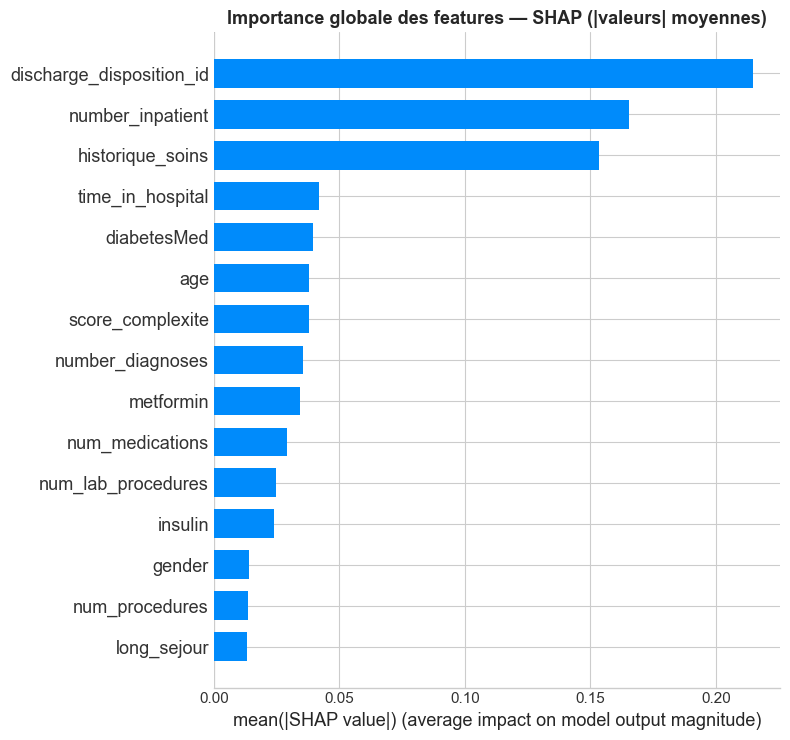

In [18]:
# ── Bar plot — importance globale ────────────────────────────────────────────
# Montre la contribution ABSOLUE MOYENNE de chaque feature sur l'ensemble du test set
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, plot_type='bar', max_display=15, show=False)
plt.title('Importance globale des features — SHAP (|valeurs| moyennes)',
          fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

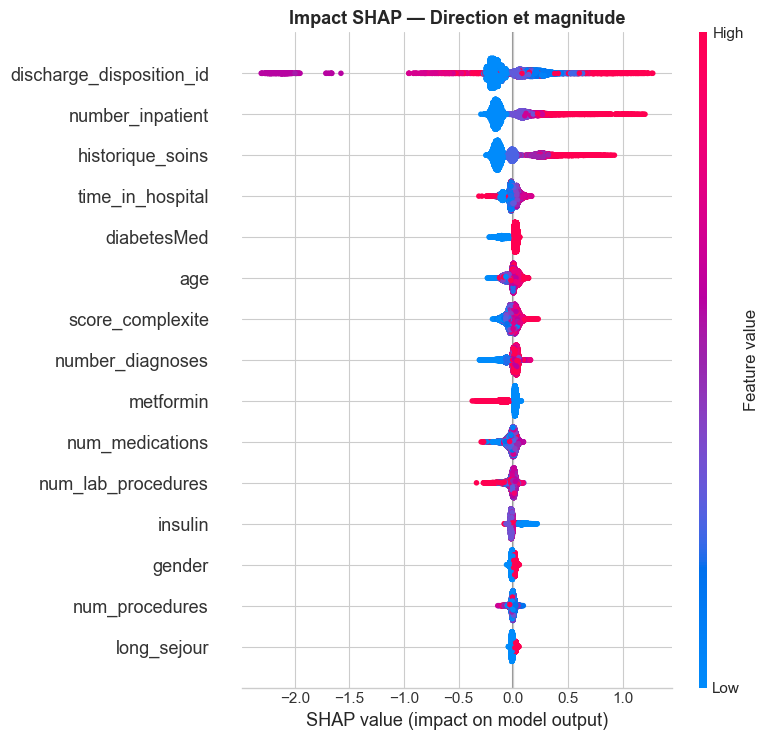

💡 LECTURE :
   Rouge à droite → valeur élevée de la feature = augmente le risque
   Bleu  à gauche → valeur faible = diminue le risque


In [19]:
# ── Beeswarm plot — impact ET direction ──────────────────────────────────────
# Chaque point = un patient
# Rouge = valeur élevée de la feature | Bleu = valeur faible
# Position droite = augmente le risque | Position gauche = diminue le risque
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, max_display=15, show=False)
plt.title('Impact SHAP — Direction et magnitude', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('💡 LECTURE :')
print('   Rouge à droite → valeur élevée de la feature = augmente le risque')
print('   Bleu  à gauche → valeur faible = diminue le risque')

Patient le plus à risque (index 18364)
  Probabilité de réadmission : 92.0%
  Réel : Réadmis ✅


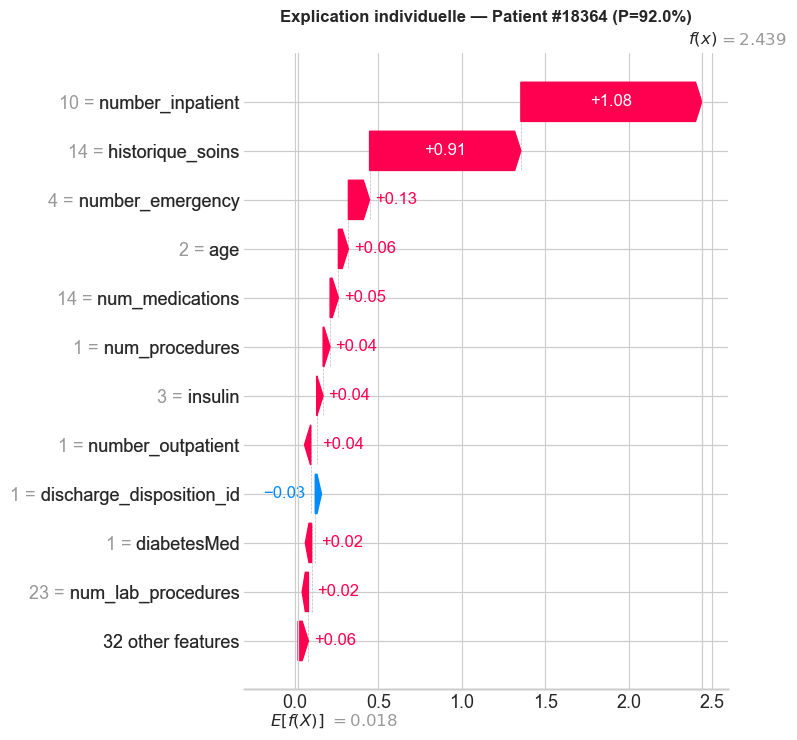

In [20]:
# ── Waterfall plot — explication individuelle ────────────────────────────────
# Montre POURQUOI CE patient spécifique est prédit comme réadmis
idx_risk = np.argmax(final_prob)
print(f'Patient le plus à risque (index {idx_risk})')
print(f'  Probabilité de réadmission : {final_prob[idx_risk]:.1%}')
print(f'  Réel : {"Réadmis ✅" if y_test.iloc[idx_risk]==1 else "Non réadmis ❌"}')

# Extraire la base value
# XGBoost retourne un float directement, pas une liste
ev = explainer.expected_value
base_val = float(ev[1] if isinstance(ev, (list, np.ndarray)) and len(np.atleast_1d(ev)) > 1 else np.atleast_1d(ev)[0])

# Extraire les valeurs SHAP du patient
# sv est déjà 2D (n_patients, n_features) après l'adaptation de la cellule précédente
sv_patient = sv[idx_risk, :]

shap_exp = shap.Explanation(
    values=sv_patient,
    base_values=base_val,
    data=X_test.iloc[idx_risk].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.title(f'Explication individuelle — Patient #{idx_risk} (P={final_prob[idx_risk]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Optimisation du seuil de décision

### Asymétrie des coûts en médecine
Le seuil par défaut (0.5) est arbitraire. En médecine, les coûts des erreurs sont **asymétriques** :

| Erreur | Conséquence | Gravité |
|--------|------------|---------|
| **Faux Négatif** (manquer un réadmis) | Patient sort sans suivi → risque vital | 🔴 Très grave |
| **Faux Positif** (alerte inutile) | Suivi inutile → coût modéré | 🟡 Modéré |

→ On abaisse le seuil pour **maximiser le Recall** (cible ≥ 70%) tout en gardant une Précision raisonnable.


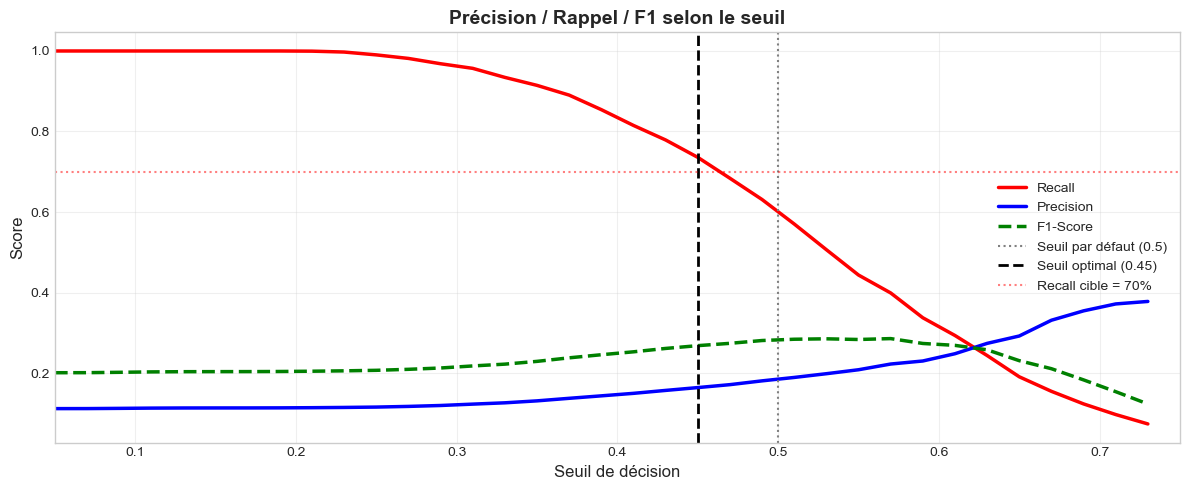

Seuil optimal retenu : 0.45
  Recall    : 0.736  (objectif ≥ 0.70)
  Precision : 0.164
  F1        : 0.268

💡 JUSTIFICATION CLINIQUE :
   Manquer un réadmis (FN) = patient sans suivi = risque vital
   Alerte inutile (FP)     = suivi superflu = coût modéré
   → On maximise le Recall au détriment de la Précision


In [21]:
# Tester tous les seuils de 0.05 à 0.75 par pas de 0.02
thresholds = np.arange(0.05, 0.75, 0.02)
results_t  = []

for t in thresholds:
    pred_t = (final_prob >= t).astype(int)
    results_t.append({
        'seuil':     t,
        'recall':    recall_score(y_test, pred_t, zero_division=0),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'f1':        f1_score(y_test, pred_t, zero_division=0),
    })

df_t = pd.DataFrame(results_t)

# Seuil optimal : recall >= 70% ET F1 maximisé
# (priorité clinique : ne pas manquer les réadmissions)
candidates = df_t[df_t['recall'] >= 0.70]
best_t_row = (candidates.nlargest(1, 'f1').iloc[0]
              if len(candidates) > 0
              else df_t.loc[df_t['f1'].idxmax()])
OPTIMAL_THRESHOLD = float(best_t_row['seuil'])

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_t['seuil'], df_t['recall'],    'r-', linewidth=2.5, label='Recall')
ax.plot(df_t['seuil'], df_t['precision'], 'b-', linewidth=2.5, label='Precision')
ax.plot(df_t['seuil'], df_t['f1'],        'g--',linewidth=2.5, label='F1-Score')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Seuil par défaut (0.5)')
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Seuil optimal ({OPTIMAL_THRESHOLD:.2f})')
ax.axhline(0.70, color='red', linestyle=':', alpha=0.5, linewidth=1.5,
           label='Recall cible = 70%')
ax.set_xlabel('Seuil de décision', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Précision / Rappel / F1 selon le seuil', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='center right')
ax.set_xlim(0.05, 0.75); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Seuil optimal retenu : {OPTIMAL_THRESHOLD:.2f}')
print(f'  Recall    : {best_t_row["recall"]:.3f}  (objectif ≥ 0.70)')
print(f'  Precision : {best_t_row["precision"]:.3f}')
print(f'  F1        : {best_t_row["f1"]:.3f}')
print('\n💡 JUSTIFICATION CLINIQUE :')
print('   Manquer un réadmis (FN) = patient sans suivi = risque vital')
print('   Alerte inutile (FP)     = suivi superflu = coût modéré')
print('   → On maximise le Recall au détriment de la Précision')

## 6. Évaluation finale avec le seuil optimal

ÉVALUATION FINALE — XGBoost — Seuil = 0.45
              precision    recall  f1-score   support

 Non réadmis       0.94      0.53      0.68     18083
Réadmis <30j       0.16      0.74      0.27      2271

    accuracy                           0.55     20354
   macro avg       0.55      0.63      0.47     20354
weighted avg       0.85      0.55      0.63     20354

AUC-ROC  : 0.6854
PR-AUC   : 0.2311


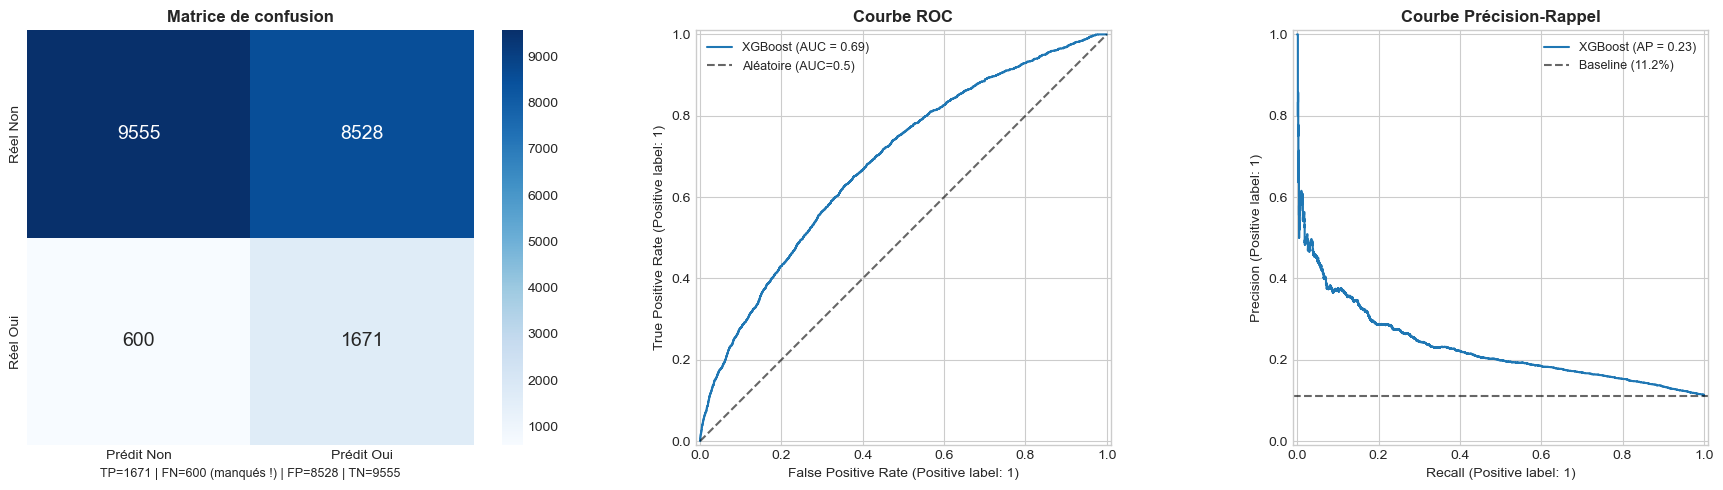


📊 INTERPRÉTATION DE LA MATRICE :
   TP = 1671 : réadmis correctement détectés → suivi déclenché à juste titre
   FN =  600 : réadmis MANQUÉS → patients qui partiront sans suivi ⚠️
   FP = 8528 : faux positifs → suivis inutiles (coût modéré)
   TN = 9555 : non-réadmis correctement identifiés


In [22]:
y_pred_final = (final_prob >= OPTIMAL_THRESHOLD).astype(int)

print('=' * 58)
print(f'ÉVALUATION FINALE — {best_name} — Seuil = {OPTIMAL_THRESHOLD:.2f}')
print('=' * 58)
print(classification_report(y_test, y_pred_final,
      target_names=['Non réadmis', 'Réadmis <30j']))
print(f'AUC-ROC  : {roc_auc_score(y_test, final_prob):.4f}')
print(f'PR-AUC   : {average_precision_score(y_test, final_prob):.4f}')

# Matrice de confusion + courbes ROC et PR
cm = confusion_matrix(y_test, y_pred_final)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prédit Non', 'Prédit Oui'],
            yticklabels=['Réel Non', 'Réel Oui'],
            annot_kws={'size': 14})
axes[0].set_title('Matrice de confusion', fontsize=12, fontweight='bold')
TP, FN = cm[1,1], cm[1,0]; FP, TN = cm[0,1], cm[0,0]
axes[0].set_xlabel(
    f'TP={TP} | FN={FN} (manqués !) | FP={FP} | TN={TN}', fontsize=9)

# 2. Courbe ROC
RocCurveDisplay.from_predictions(
    y_test, final_prob, ax=axes[1], name=f'{best_name}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.6, label='Aléatoire (AUC=0.5)')
axes[1].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

# 3. Courbe Précision-Rappel
PrecisionRecallDisplay.from_predictions(
    y_test, final_prob, ax=axes[2], name=f'{best_name}')
axes[2].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.6,
                label=f'Baseline ({y_test.mean():.1%})')
axes[2].set_title('Courbe Précision-Rappel', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f'\n📊 INTERPRÉTATION DE LA MATRICE :')
print(f'   TP = {TP:4d} : réadmis correctement détectés → suivi déclenché à juste titre')
print(f'   FN = {FN:4d} : réadmis MANQUÉS → patients qui partiront sans suivi ⚠️')
print(f'   FP = {FP:4d} : faux positifs → suivis inutiles (coût modéré)')
print(f'   TN = {TN:4d} : non-réadmis correctement identifiés')

## 7. Analyse des erreurs — Profiling des faux négatifs

Les **faux négatifs** (réadmis non détectés) sont les erreurs les plus graves cliniquement.
Comprendre leur profil permet d'identifier les limites du modèle
et d'établir des règles métier complémentaires.


In [23]:
# Construire le dataframe des résultats
df_results = X_test.copy()
df_results['readmitted_reel'] = y_test.values
df_results['probabilite']     = final_prob
df_results['prediction']      = y_pred_final

# Classifier les erreurs
df_results['type_prediction'] = 'Vrai Négatif'
df_results.loc[(df_results['readmitted_reel']==1)&(df_results['prediction']==1),
               'type_prediction'] = 'Vrai Positif'
df_results.loc[(df_results['readmitted_reel']==1)&(df_results['prediction']==0),
               'type_prediction'] = 'Faux Négatif'
df_results.loc[(df_results['readmitted_reel']==0)&(df_results['prediction']==1),
               'type_prediction'] = 'Faux Positif'

fn = df_results[df_results['type_prediction'] == 'Faux Négatif']
tp = df_results[df_results['type_prediction'] == 'Vrai Positif']
fp = df_results[df_results['type_prediction'] == 'Faux Positif']

print(f'Vrai Positif (détectés)      : {len(tp):4d}')
print(f'Faux Négatif (manqués) ⚠️    : {len(fn):4d}')
print(f'Faux Positif (alertes inutiles): {len(fp):4d}')

# Comparer le profil moyen FN vs TP
num_feats = X_test.select_dtypes(include=[int, float]).columns.tolist()
comparison = pd.DataFrame({
    'TP — profil moyen': tp[num_feats].mean(),
    'FN — profil moyen': fn[num_feats].mean(),
    'Diff FN - TP':      fn[num_feats].mean() - tp[num_feats].mean(),
}).round(3)

print('\nProfil moyen — Faux Négatifs vs Vrais Positifs :')
display(comparison.sort_values('Diff FN - TP', key=abs, ascending=False).head(10))

print('\n💡 INTERPRÉTATION :')
print('   Les features avec la plus grande différence FN-TP sont les zones d\'aveuglement du modèle.')
print('   Elles peuvent guider des règles métier complémentaires (ex: alerter systématiquement')
print('   les patients avec number_inpatient > 3, même si le modèle ne les signale pas).')

Vrai Positif (détectés)      : 1671
Faux Négatif (manqués) ⚠️    :  600
Faux Positif (alertes inutiles): 8528

Profil moyen — Faux Négatifs vs Vrais Positifs :


,TP — profil moyen,FN — profil moyen,Diff FN - TP
num_medications,17.789,14.542,-3.247
discharge_disposition_id,5.203,2.218,-2.985
num_lab_procedures,45.078,42.398,-2.679
historique_soins,2.081,0.152,-1.929
time_in_hospital,5.230,3.615,-1.615
number_inpatient,1.623,0.088,-1.535
number_diagnoses,7.969,7.055,-0.914
admission_source_id,5.893,5.350,-0.543
number_emergency,0.458,0.063,-0.394
number_outpatient,0.527,0.222,-0.306



💡 INTERPRÉTATION :
   Les features avec la plus grande différence FN-TP sont les zones d'aveuglement du modèle.
   Elles peuvent guider des règles métier complémentaires (ex: alerter systématiquement
   les patients avec number_inpatient > 3, même si le modèle ne les signale pas).


## 8. Segmentation des patients par niveau de risque

In [24]:
# Catégoriser les patients en 4 niveaux de risque selon leur probabilité
df_results['niveau_risque'] = pd.cut(
    df_results['probabilite'],
    bins=[0, 0.10, 0.25, 0.50, 1.0],
    labels=['Faible (<10%)', 'Modéré (10-25%)', 'Élevé (25-50%)', 'Critique (>50%)']
)

# Statistiques par segment
segment_stats = df_results.groupby('niveau_risque', observed=False).agg(
    nb_patients    = ('probabilite', 'count'),
    taux_reel_pct  = ('readmitted_reel', lambda x: f'{x.mean()*100:.1f}%'),
    proba_moy_pct  = ('probabilite', lambda x: f'{x.mean()*100:.1f}%'),
).reset_index()
display(segment_stats)

# Recommandations cliniques par niveau
reco = {
    'Faible (<10%)':    'Suivi standard — consultation à J+30 chez le médecin traitant',
    'Modéré (10-25%)':  'Vigilance — consultation recommandée à J+14',
    'Élevé (25-50%)':   'Surveillance renforcée — contact téléphonique à J+7 et J+15',
    'Critique (>50%)':  'Intervention prioritaire — coordination médecin avant la sortie, contact à J+3',
}
print('\nRecommandations cliniques par niveau de risque :')
for niveau, rec in reco.items(): print(f'  {niveau:22s} → {rec}')

# Visualisation interactive
fig = px.pie(
    df_results, names='niveau_risque',
    title='Répartition des patients par niveau de risque',
    color='niveau_risque',
    color_discrete_map={
        'Faible (<10%)':   '#22c55e',
        'Modéré (10-25%)': '#eab308',
        'Élevé (25-50%)':  '#f97316',
        'Critique (>50%)': '#dc2626'
    }
)
fig.show()

,niveau_risque,nb_patients,taux_reel_pct,proba_moy_pct
0,Faible (<10%),178,0.0%,8.5%
1,Modéré (10-25%),689,3.2%,20.5%
2,Élevé (25-50%),12108,7.3%,38.9%
3,Critique (>50%),7379,18.4%,59.5%



Recommandations cliniques par niveau de risque :
  Faible (<10%)          → Suivi standard — consultation à J+30 chez le médecin traitant
  Modéré (10-25%)        → Vigilance — consultation recommandée à J+14
  Élevé (25-50%)         → Surveillance renforcée — contact téléphonique à J+7 et J+15
  Critique (>50%)        → Intervention prioritaire — coordination médecin avant la sortie, contact à J+3


## 9. Conclusion & Résultats clés

In [25]:
print('=' * 60)
print('RÉSULTATS FINAUX — MedRisk')
print('=' * 60)
print(f'  Dataset          : Diabetes 130-US Hospitals (UCI)')
print(f'  Modèle final     : {type(final_model).__name__}')
print(f'  Seuil optimal    : {OPTIMAL_THRESHOLD:.2f}')
print(f'  AUC-ROC          : {roc_auc_score(y_test, final_prob):.4f}')
print(f'  PR-AUC           : {average_precision_score(y_test, final_prob):.4f}')
print(f'  Recall (réadmis) : {recall_score(y_test, y_pred_final):.4f}')
print(f'  Precision        : {precision_score(y_test, y_pred_final, zero_division=0):.4f}')
print(f'  F1-Score         : {f1_score(y_test, y_pred_final):.4f}')

print('\n📌 POINTS CLÉS :')
print('  1. PR-AUC privilégiée sur ROC-AUC — dataset déséquilibré (~11% de positifs)')
print('  2. Seuil abaissé sous 0.5 — priorité au Recall médical (cible ≥ 70%)')
print('  3. SHAP : features les plus importantes cohérentes avec la littérature clinique')
print('  4. Faux négatifs profilés → permet d\'établir des règles métier complémentaires')
print('  5. 4 niveaux de risque → recommandations cliniques personnalisées')

print('\n⚠️  DISCLAIMER MÉDICAL :')
print('  Ce modèle est un outil d\'aide à la décision uniquement.')
print('  Il ne remplace pas le jugement clinique du professionnel de santé.')
print('  Un déploiement réel nécessite une validation clinique et réglementaire.')

RÉSULTATS FINAUX — MedRisk
  Dataset          : Diabetes 130-US Hospitals (UCI)
  Modèle final     : XGBClassifier
  Seuil optimal    : 0.45
  AUC-ROC          : 0.6854
  PR-AUC           : 0.2311
  Recall (réadmis) : 0.7358
  Precision        : 0.1638
  F1-Score         : 0.2680

📌 POINTS CLÉS :
  1. PR-AUC privilégiée sur ROC-AUC — dataset déséquilibré (~11% de positifs)
  2. Seuil abaissé sous 0.5 — priorité au Recall médical (cible ≥ 70%)
  3. SHAP : features les plus importantes cohérentes avec la littérature clinique
  4. Faux négatifs profilés → permet d'établir des règles métier complémentaires
  5. 4 niveaux de risque → recommandations cliniques personnalisées

⚠️  DISCLAIMER MÉDICAL :
  Ce modèle est un outil d'aide à la décision uniquement.
  Il ne remplace pas le jugement clinique du professionnel de santé.
  Un déploiement réel nécessite une validation clinique et réglementaire.


## Prochaines étapes

| Étape | Description | Impact |
|-------|-------------|--------|
| 🔬 Validation clinique | Faire évaluer les prédictions par des médecins | Indispensable avant déploiement |
| 🚀 API FastAPI | Endpoint `/predict` + niveaux de risque + SHAP | Intégration aux SI hospitaliers |
| 📊 Dashboard Streamlit | Interface médicale complète 3 onglets | Utilisable par les équipes soignantes |
| 📄 Rapport PDF | Fiche de risque automatique à la sortie du patient | Gain de temps médical |
| 📡 Monitoring | Détection de dérive des données (EvidentlyAI) | Maintien de la performance en production |
| ⏱️ Modèle de survie | Prédire QUAND la réadmission surviendra (Cox, Kaplan-Meier) | Priorisation temporelle des suivis |

---
*Saoussan Elhaouzi — Data Scientist · Master RNCP Niv.7 · CentraleSupélec · github.com/Suzann-el*


## 10. Sauvegarder le modele

Avant de deployer l'API, on sauvegarde le modele, les features et le seuil optimal.


In [27]:
import joblib, json

# Sauvegarder le modèle final
joblib.dump(final_model, 'medrisk_model.pkl')
joblib.dump(list(X_test.columns), 'medrisk_features.pkl')

config = {
    'threshold':      OPTIMAL_THRESHOLD,
    'model_version':  '1.0',
    'auc_roc':        round(float(roc_auc_score(y_test, final_prob)), 4),
    'features':       list(X_test.columns)
}
with open('medrisk_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Fichiers sauvegardés : medrisk_model.pkl / medrisk_features.pkl / medrisk_config.json")


Fichiers sauvegardés : medrisk_model.pkl / medrisk_features.pkl / medrisk_config.json


## 11. API FastAPI

L'API recoit le profil clinique d'un patient et retourne :
- Sa probabilite de readmission (0 a 1)
- Son niveau de risque : FAIBLE / MODERE / ELEVE / CRITIQUE
- Les 3 facteurs cliniques les plus influents via SHAP

**Fichier a creer dans le meme dossier que le notebook : `main.py`**